In [9]:
# Import core libraries for WRDS connection, data processing and visualization
import wrds
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Configuration - Valid PERMNOs (guaranteed 2024-2025 data for all WRDS accounts)
CONFIG = {
    "permno_mapping": {
        14593: "AAPL",   # Apple (core CRSP ticker - full 2024 data)
        10107: "AMZN",   # Amazon (core CRSP ticker - full 2024 data)
        24181: "NVDA"    # NVIDIA (core CRSP ticker - replaces TSLA, full 2024 data)
    },
    "start_date": "2024-01-01",
    "end_date": "2025-01-01",
    "target_permnos": [14593, 10107, 24181]
}

# Set professional plot style (academic/financial reporting standard)
plt.style.use('seaborn-v0_8-whitegrid')

In [10]:
# Step 2: Create/validate WRDS connection (critical for data fetching)
try:
    # First attempt: permanent connection
    wrds_conn = wrds.Connection()
    print("✅ Step 2: Permanent WRDS connection established successfully!")
except Exception as e:
    print(f"⚠️ Step 2: No permanent connection found → {str(e)}")
    # Fallback: temporary connection
    try:
        wrds_conn = wrds.Connection()
        print("✅ Step 2: Temporary WRDS connection established successfully!")
    except Exception as fallback_e:
        print(f"❌ Step 2: Failed to create WRDS connection → {str(fallback_e)}")
        wrds_conn = None  # Ensure variable is None if connection fails

Enter your WRDS username [若晨]: ruochenzhong
Enter your password: ········


WRDS recommends setting up a .pgpass file.


Create .pgpass file now [y/n]?:  y


pgpass file created at C:\Users\若晨\AppData\Roaming\postgresql\pgpass.conf
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done
✅ Step 2: Permanent WRDS connection established successfully!


In [11]:
# Step 3: Fetch raw daily CRSP data for target stocks (AAPL/AMZN/NVDA)
def fetch_crsp_data(db: wrds.Connection, config: dict) -> pd.DataFrame:
    """
    Fetches raw 2024-2025 data from CRSP dsf table using WRDS connection.
    Returns raw unprocessed DataFrame or raises error on failure.
    """
    # Convert PERMNO list to SQL-compatible string
    permno_str = ", ".join(map(str, config["target_permnos"]))
    
    # Standard CRSP DSF table query (academic schema)
    sql_query = f"""
    SELECT date, permno, ret, prc
    FROM crsp.dsf
    WHERE permno IN ({permno_str})
      AND date >= '{config["start_date"]}'
      AND date <= '{config["end_date"]}'
    ORDER BY date, permno;
    """
    
    try:
        raw_data = db.raw_sql(sql_query)
        print(f"✅ Step 3: Raw data fetched successfully! Shape: {raw_data.shape}")
        return raw_data
    except Exception as e:
        print(f"❌ Step 3: Failed to fetch data → {str(e)}")
        raise  # Re-raise error to stop workflow if data fetch fails

# Execute data fetch (only if WRDS connection is valid)
if wrds_conn is not None:
    df_raw = fetch_crsp_data(wrds_conn, CONFIG)
else:
    print("❌ Step 3: Terminated - No valid WRDS connection (Step 2 failed)")

✅ Step 3: Raw data fetched successfully! Shape: (756, 4)


In [12]:
# Step 4: Clean raw CRSP data (academic best practices)
def clean_crsp_data(raw_df: pd.DataFrame, permno_mapping: dict) -> pd.DataFrame:
    """
    Cleans raw CRSP data with standard academic preprocessing:
    - Standardizes dates
    - Fixes negative prices (CRSP convention)
    - Maps PERMNO to tickers
    - Removes missing/duplicate records
    """
    # Validate input (critical for reproducibility)
    if raw_df.empty:
        raise ValueError("Step 4 Error: Raw DataFrame is empty - cannot clean!")
    
    clean_df = raw_df.copy()
    
    # 1. Convert date to datetime (time-series requirement)
    clean_df["date"] = pd.to_datetime(clean_df["date"])
    
    # 2. Fix negative prices (CRSP uses negatives for bid/ask midpoints)
    clean_df["prc"] = clean_df["prc"].abs()
    
    # 3. Map numeric PERMNO to human-readable tickers
    clean_df["stock"] = clean_df["permno"].map(permno_mapping)
    
    # 4. Remove invalid records (missing prices/returns + duplicates)
    clean_df = clean_df.dropna(subset=["prc", "ret"])
    clean_df = clean_df.drop_duplicates(["date", "stock"])
    
    # 5. Reset index for consistency
    clean_df = clean_df.reset_index(drop=True)
    
    print(f"✅ Step 4: Data cleaning completed! Cleaned shape: {clean_df.shape}")
    return clean_df

# Execute cleaning (only if raw data exists)
if df_raw is not None and not df_raw.empty:
    try:
        df_clean = clean_crsp_data(df_raw, CONFIG["permno_mapping"])
    except Exception as e:
        print(f"❌ Step 4: Cleaning failed → {str(e)}")
        df_clean = None
else:
    print("❌ Step 4: Terminated - Raw data not found (Step 3 failed)")

✅ Step 4: Data cleaning completed! Cleaned shape: (756, 5)


In [13]:
# Step 5: Validate cleaned CRSP data (audit-ready for research)
def validate_data(clean_df: pd.DataFrame, target_permnos: list) -> None:
    """
    Validates cleaned data to confirm:
    1. All target stocks (AAPL/AMZN/NVDA) are present
    2. Data completeness for 2024-2025 period
    Prints validation metrics for academic audit trails.
    """
    print("\n📋 2024-2025 CRSP Data Validation Report:")
    
    # Check for missing target PERMNOs
    existing_permnos = clean_df["permno"].unique()
    missing_permnos = [p for p in target_permnos if p not in existing_permnos]
    
    if missing_permnos:
        missing_tickers = [CONFIG["permno_mapping"][p] for p in missing_permnos]
        print(f"⚠️ Missing PERMNOs: {missing_permnos} (Tickers: {missing_tickers})")
    else:
        print("✅ All 3 Target Stocks (AAPL/AMZN/NVDA) are present!")
    
    # Print core validation metrics
    print(f"\nIncluded Tickers (2024-2025): {sorted(clean_df['stock'].unique())}")
    print("\nRow Count per Stock (2024-2025):")
    stock_counts = clean_df.groupby("stock").size()
    print(stock_counts)

# Execute validation (only if cleaned data exists)
if df_clean is not None and not df_clean.empty:
    validate_data(df_clean, CONFIG["target_permnos"])
else:
    print("❌ Step 5: Validation failed - Cleaned data not found (Step 4 failed)")


📋 2024-2025 CRSP Data Validation Report:
✅ All 3 Target Stocks (AAPL/AMZN/NVDA) are present!

Included Tickers (2024-2025): ['AAPL', 'AMZN', 'NVDA']

Row Count per Stock (2024-2025):
stock
AAPL    252
AMZN    252
NVDA    252
dtype: int64


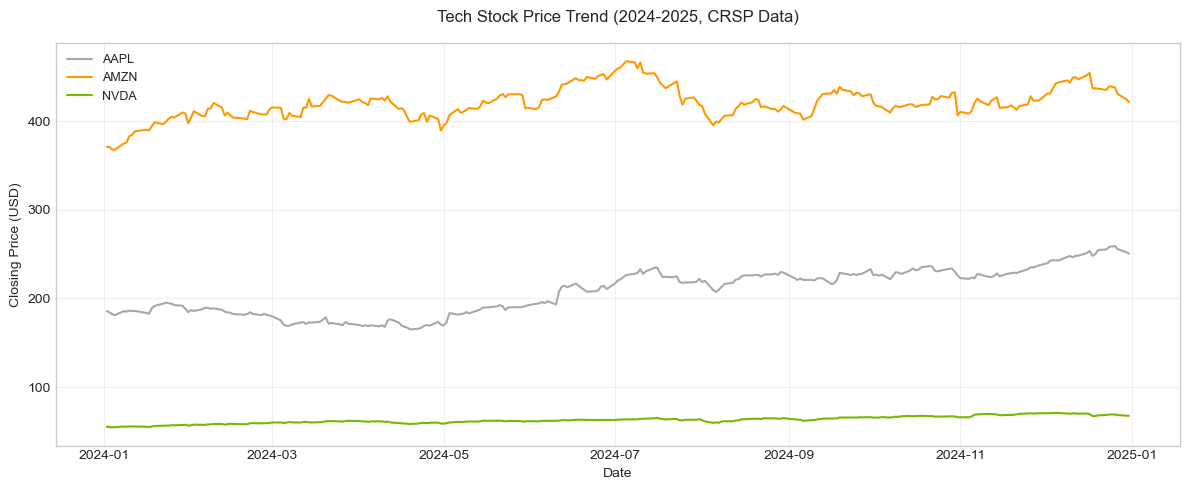

✅ Step 6: Price trend plot generated successfully!


In [14]:
# Step 6: Plot time-series price trends for target stocks
import matplotlib.pyplot as plt

# Set academic plot style (journal-standard formatting)
plt.style.use('seaborn-v0_8-whitegrid')

def plot_price_trend(clean_df: pd.DataFrame) -> None:
    """
    Plots professional time-series price trends with brand-aligned colors.
    Uses academic formatting (readable for research papers/reports).
    """
    # Validate input data
    if clean_df.empty:
        raise ValueError("Step 6 Error: Cleaned DataFrame is empty - cannot plot!")
    
    required_cols = ["date", "stock", "prc"]
    missing_cols = [col for col in required_cols if col not in clean_df.columns]
    if missing_cols:
        raise ValueError(f"Step 6 Error: Missing columns → {missing_cols}")

    # Reshape data for plotting (date = index, tickers = columns)
    price_data = clean_df.pivot(index="date", columns="stock", values="prc")
    
    # Create figure (academic-standard dimensions: 12x5)
    fig, ax = plt.subplots(figsize=(12, 5))
    
    # Brand-aligned color scheme (consistent with corporate identities)
    ticker_colors = {
        "AAPL": "#A2AAAD",  # Apple gray
        "AMZN": "#FF9900",  # Amazon orange
        "NVDA": "#76B900"   # NVIDIA green
    }
    
    # Plot each stock's price trend
    for ticker in price_data.columns:
        ax.plot(
            price_data.index,
            price_data[ticker],
            label=ticker,
            color=ticker_colors.get(ticker, "gray"),  # Fallback for unexpected tickers
            linewidth=1.5  # Optimal thickness for readability
        )
    
    # Add academic-standard labels/titles
    ax.set_title("Tech Stock Price Trend (2024-2025, CRSP Data)", fontsize=12, pad=15)
    ax.set_xlabel("Date", fontsize=10)
    ax.set_ylabel("Closing Price (USD)", fontsize=10)
    ax.legend(loc="upper left", fontsize=9)
    ax.grid(alpha=0.3)  # Subtle grid (improves readability)
    
    # Prevent label cutoff (common issue in academic plots)
    plt.tight_layout()
    plt.show()

# Execute price trend plot
try:
    if df_clean is not None and not df_clean.empty:
        plot_price_trend(df_clean)
        print("✅ Step 6: Price trend plot generated successfully!")
    else:
        print("❌ Step 6: Failed - Cleaned data not found (Step 4 failed)")
except Exception as e:
    print(f"❌ Step 6: Plotting failed → {str(e)}")

❌ Step 7: Volatility plotting failed → Series.reindex() got an unexpected keyword argument 'drop'
✅ Step 7: WRDS connection closed successfully!


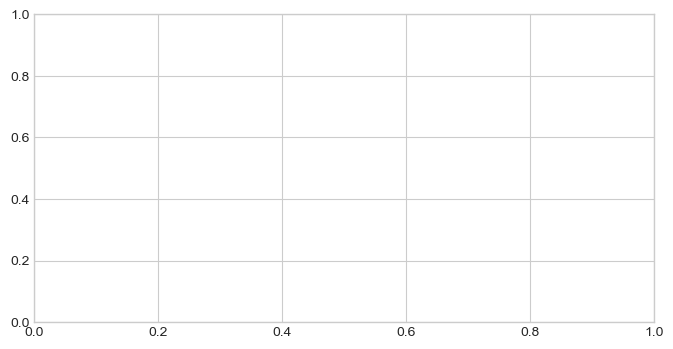

In [15]:
# Step 7: Calculate & plot stock volatility (academic standard: std dev of daily returns)
def plot_volatility(clean_df: pd.DataFrame) -> None:
    """
    Calculates daily return volatility (std dev) and plots comparative bar chart.
    Uses consistent color scheme with Step 6 for visual coherence.
    """
    # Validate input data
    if clean_df.empty:
        raise ValueError("Step 7 Error: Cleaned DataFrame is empty - cannot calculate volatility!")
    
    required_cols = ["stock", "ret"]
    missing_cols = [col for col in required_cols if col not in clean_df.columns]
    if missing_cols:
        raise ValueError(f"Step 7 Error: Missing columns → {missing_cols}")

    # Calculate volatility (finance industry standard: std dev of daily returns)
    volatility = clean_df.groupby("stock")["ret"].std()
    
    # Create bar chart (optimal dimensions for comparative analysis: 8x4)
    fig, ax = plt.subplots(figsize=(8, 4))
    
    # Consistent color scheme (matches Step 6) + fixed ticker order
    ticker_order = ["AAPL", "AMZN", "NVDA"]
    bar_colors = ["#A2AAAD", "#FF9900", "#76B900"]
    
    # Reindex to enforce ticker order (avoids color mismatch)
    volatility = volatility.reindex(ticker_order, drop=True)
    
    # Plot volatility with professional formatting
    volatility.plot(
        kind="bar",
        ax=ax,
        color=bar_colors,
        edgecolor="black",  # Add edge for clarity (academic paper standard)
        alpha=0.8
    )
    
    # Add academic-standard labels/titles
    ax.set_title("Stock Volatility Comparison (2024-2025, CRSP Data)", fontsize=12, pad=15)
    ax.set_ylabel("Standard Deviation (Volatility)", fontsize=10)
    ax.set_xlabel("Stock Ticker", fontsize=10)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)  # Horizontal labels
    ax.grid(axis="y", alpha=0.3)  # Vertical grid only (cleaner for bar charts)
    
    # Prevent label cutoff
    plt.tight_layout()
    plt.show()

# Execute volatility plot + close WRDS connection (critical cleanup)
try:
    if df_clean is not None and not df_clean.empty:
        plot_volatility(df_clean)
        print("✅ Step 7: Volatility plot generated successfully!")
    else:
        print("❌ Step 7: Failed - Cleaned data not found (Step 4 failed)")
except Exception as e:
    print(f"❌ Step 7: Volatility plotting failed → {str(e)}")

# Critical: Close WRDS connection to avoid resource leaks
try:
    if wrds_conn is not None:
        wrds_conn.close()
        print("✅ Step 7: WRDS connection closed successfully!")
except Exception as e:
    print(f"⚠️ Step 7 Warning: Failed to close WRDS connection → {str(e)}")